In [5]:
import pandas as pd
import numpy as np
import re
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
filepath = '../data/cleanedNairobi_RE_Prices.csv'
df = pd.read_csv(filepath)

In [8]:
df.head()

,Location,Bedroom,bathroom,Price,House_size_sqm,LandSize_acres,propertyType
0,Runda,4.0,4.0,350000000,NaN,0.5,Townhouse
1,Karen,NaN,NaN,30000000,NaN,0.5,Vacant Land
2,Westlands,NaN,NaN,325000000,NaN,0.5,Vacant Land
3,Kitisuru,5.0,5.0,80000000,NaN,0.5,Townhouse
4,Kileleshwa,4.0,4.0,25500000,230.0,NaN,Apartment


#### 🛠️Exploratory Data Analysis

###### Price distribution

In [9]:
px.histogram(df, x='Price', nbins=50, title='Distribution of Prices')

###### Property Type Frequency

In [12]:
#df['propertyType'].value_counts().reset_index()
fig2 = px.bar(
    df['propertyType'].value_counts().reset_index(),
    x='count',
    y='propertyType',
    title='Frequency of Property Types',
    labels={'propertyType': ''}
)
fig2.show()

###### Avg. Price by Property Type

In [19]:
#df.groupby('propertyType')['Price'].mean().reset_index().sort_values(by='Price', ascending=False)
fig3 = px.bar(
    df.groupby('propertyType')['Price'].mean().reset_index().sort_values(by='Price', ascending=False),
    x = 'propertyType',
    y = 'Price',
    title = 'Avg. Price by Property Type',
    labels={'Price': 'Price [Ksh]', 'propertyType': ''}
)
fig3.show()

###### Price vs. House Size

In [22]:
fig4 = px.scatter(
    df,
    x ='House_size_sqm',
    y = 'Price',
    title = 'Price vs House Size (sqm)',
    trendline='ols'
)
fig4.show()

###### Avg. Price by Location (Top 10)

In [28]:
df.groupby('Location')['Price'].mean().reset_index().sort_values(by='Price', ascending=False)
fig5 = px.bar(
    df.groupby('Location')['Price'].mean().reset_index().sort_values(by='Price', ascending=False),
    x = 'Price',
    y = 'Location',
    title = 'Top 10 -- Avg Price by Location',
    labels = {'Location': '', 'Price': 'Price [Ksh.]'}
)
fig5.show()

###### Heatmap -- correlation of numeric features

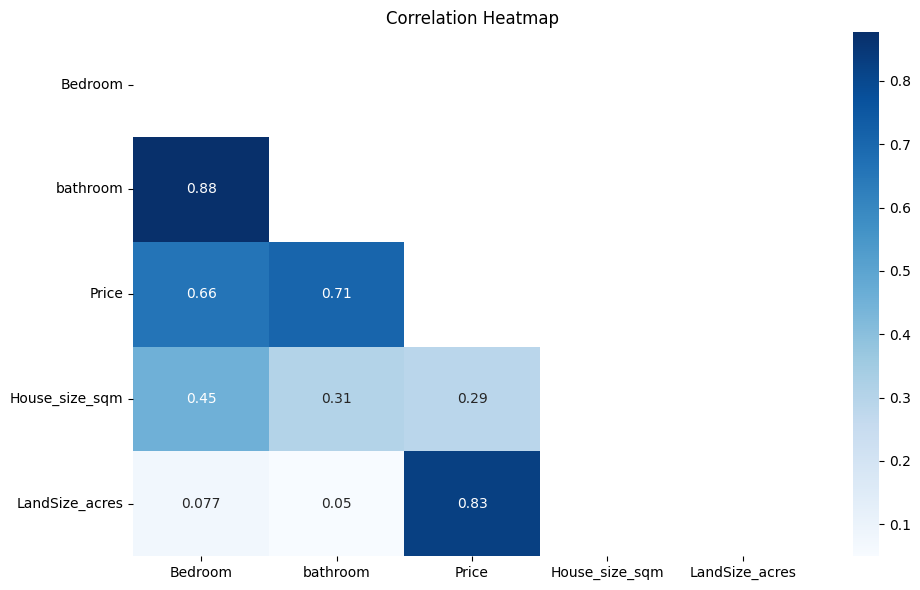

In [33]:
plt.figure(figsize=(10, 6))
mask = np.triu(np.ones_like(df.select_dtypes(include=[np.number]).corr(),dtype=bool))
sns.heatmap(
    df.select_dtypes(include=[np.number]).corr(),
    annot=True,
    cmap='Blues',
    mask=mask
)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

###### Price per sqm

In [35]:
with np.errstate(divide='ignore', invalid='ignore'):
  df['Price_per_sqm'] = df['Price'] / df['House_size_sqm']



In [38]:
df['Price_per_sqm']
fig6 = px.box(
    df,
    x = 'propertyType',
    y = 'Price_per_sqm',
    title = 'Price per sqm by Property Type'
)
fig6.show()

###### ©️ 2025 Ochieng Fess | Data Strategist